In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

I0000 00:00:1777489236.292150  995831 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777489237.276326  995831 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [3]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mfcc_img/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mfcc_img/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mfcc_img/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 7431 files belonging to 8 classes.
Found 636 files belonging to 8 classes.
Found 636 files belonging to 8 classes.


In [4]:
incv3_5 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_5.trainable = False
for layer in incv3_5.layers[-20:]:
    layer.trainable = True
model_5 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_5,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='gelu',
                   kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4),

               ),
  layers.Dropout(0.4),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_5.summary()
keras.backend.clear_session(free_memory=True)
model_5.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 2,202,760 (8.40 MB)

 Non-trainable params: 19,871,520 (75.80 MB)

In [5]:
history_5 = model_5.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - loss: 1.9803 - sparse_categorical_accuracy: 0.3588 - val_loss: 1.2087 - val_sparse_categorical_accuracy: 0.6887
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 1.3353 - sparse_categorical_accuracy: 0.5679 - val_loss: 0.8582 - val_sparse_categorical_accuracy: 0.7531
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1.1181 - sparse_categorical_accuracy: 0.6383 - val_loss: 0.7708 - val_sparse_categorical_accuracy: 0.7736
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1.0160 - sparse_categorical_accuracy: 0.6722 - val_loss: 0.7267 - val_sparse_categorical_accuracy: 0.7893
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.9299 - sparse_categorical_accuracy: 0.7053 - val_loss: 0.6993 - val_sparse_categorical_accuracy: 0.7972
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.8692 - sparse_categorical_accuracy: 0.7222 - val_loss: 0.6719 - val_sparse_categorical_accurac

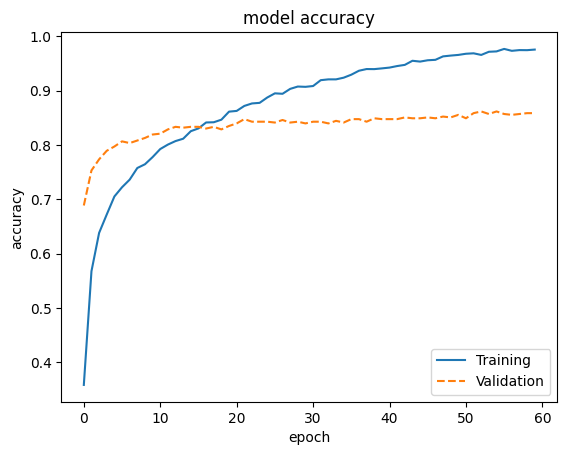

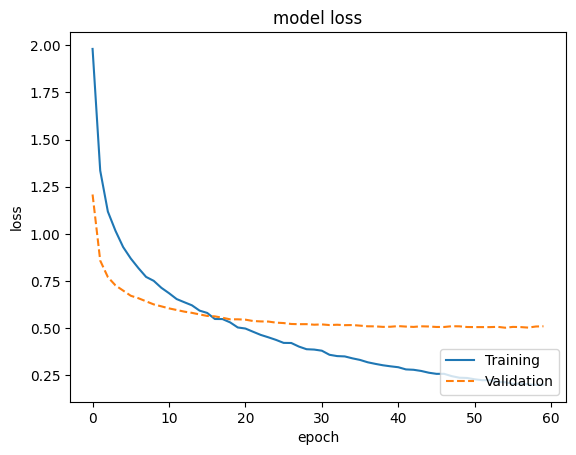

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5216 - sparse_categorical_accuracy: 0.8632


[0.521587610244751, 0.8632075190544128]

In [6]:
plt.plot(history_5.history['sparse_categorical_accuracy'])
plt.plot(history_5.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_5.evaluate(test_ds)

Classification Report:
              precision    recall  f1-score   support

       angry       0.88      0.83      0.85        88
        calm       0.59      0.79      0.68        29
     disgust       0.90      0.91      0.91        89
        fear       0.89      0.83      0.86        89
       happy       0.82      0.84      0.83        89
     neutral       0.94      0.84      0.89        74
         sad       0.88      0.88      0.88        89
   surprised       0.88      0.93      0.91        89

    accuracy                           0.86       636
   macro avg       0.85      0.86      0.85       636
weighted avg       0.87      0.86      0.86       636



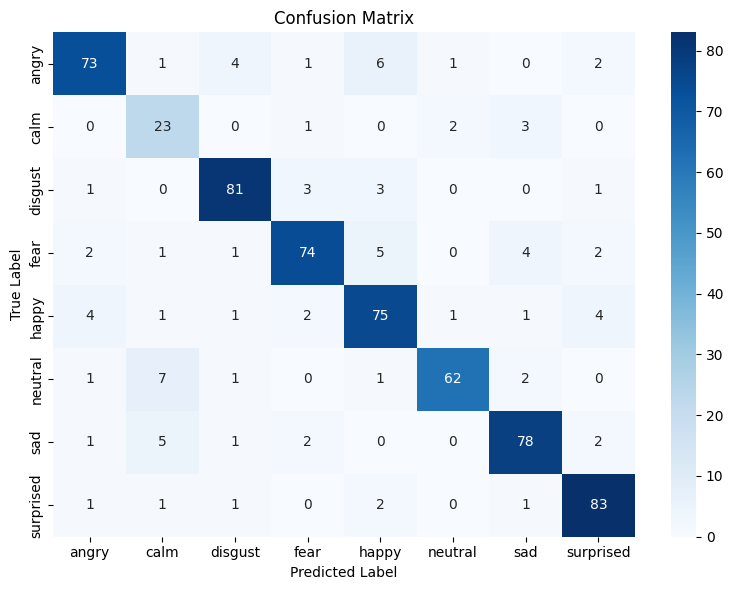

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # Get model predictions (probabilities)
    preds = model_5.predict(images, verbose=0)
    
    # Convert to class indices
    pred_classes = np.argmax(preds, axis=1)
    
    true_labels.extend(labels.numpy())
    predicted_labels.extend(pred_classes)

true_labels      = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

class_names = test_ds.class_names 


print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()